# LeetCode #133: Clone Graph

https://leetcode.com/problems/clone-graph/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| BFS with HashMap | O(n+e) | O(n) | Iterative, same complexity |
| **DFS with HashMap** | **O(n+e)** | **O(n)** | **Optimal — recursive, clean** |

## Understanding the Method

The HashMap maps `original node → cloned node`:
- Before recursing into neighbors, register the clone in the map (prevents infinite loops)
- For each neighbor: if already cloned (in map), use that clone; otherwise DFS recursively
- Works for any connected undirected graph, including cycles

## Constraints

- Number of nodes: `[0, 100]`
- `1 <= Node.val <= 100`
- Node values are unique.
- No repeated edges, no self-loops.

## Solutions

### C#

In [ ]:
public class Solution {
    Dictionary<Node, Node> map = new Dictionary<Node, Node>();
    public Node CloneGraph(Node node) {
        if (node == null) return null;
        if (map.ContainsKey(node)) return map[node];
        Node clone = new Node(node.val);
        map[node] = clone;
        foreach (var nb in node.neighbors)
            clone.neighbors.Add(CloneGraph(nb));
        return clone;
    }
}

### Python

In [ ]:
class Solution:
    def cloneGraph(self, node: 'Node') -> 'Node':
        if not node:
            return None
        cloned = {}
        def dfs(n):
            if n in cloned:
                return cloned[n]
            clone = Node(n.val)
            cloned[n] = clone
            for nb in n.neighbors:
                clone.neighbors.append(dfs(nb))
            return clone
        return dfs(node)

### Go

In [ ]:
func cloneGraph(node *Node) *Node {
    if node == nil { return nil }
    cloned := map[*Node]*Node{}
    var dfs func(*Node) *Node
    dfs = func(n *Node) *Node {
        if c, ok := cloned[n]; ok { return c }
        c := &Node{Val: n.Val}
        cloned[n] = c
        for _, nb := range n.Neighbors {
            c.Neighbors = append(c.Neighbors, dfs(nb))
        }
        return c
    }
    return dfs(node)
}

### Rust

In [ ]:
// Rust graph cloning uses Rc<RefCell<Node>> for shared ownership
use std::rc::Rc;
use std::cell::RefCell;
use std::collections::HashMap;

impl Solution {
    pub fn clone_graph(node: Option<Rc<RefCell<Node>>>) -> Option<Rc<RefCell<Node>>> {
        let mut map: HashMap<i32, Rc<RefCell<Node>>> = HashMap::new();
        fn dfs(node: &Option<Rc<RefCell<Node>>>, map: &mut HashMap<i32, Rc<RefCell<Node>>>) -> Option<Rc<RefCell<Node>>> {
            let n = node.as_ref()?;
            let val = n.borrow().val;
            if let Some(c) = map.get(&val) { return Some(Rc::clone(c)); }
            let clone = Rc::new(RefCell::new(Node::new(val)));
            map.insert(val, Rc::clone(&clone));
            let neighbors: Vec<_> = n.borrow().neighbors.clone();
            for nb in &neighbors {
                if let Some(c) = dfs(nb, map) {
                    clone.borrow_mut().neighbors.push(Some(c));
                }
            }
            Some(clone)
        }
        dfs(&node, &mut map)
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `adjList = [[2,4],[1,3],[2,4],[1,3]]` (4-node cycle: $1-2-3-4-1$)  
DFS from node 1: create clone(1), add to map. Visit neighbor 2: create clone(2). Visit neighbor 1 of node 2: already in map, return clone(1). Cycle correctly handled by HashMap lookup.  
WHY tricky: The cycle $1 \to 2 \to 1$ would cause infinite recursion without the HashMap check. Registering the clone BEFORE recursing into neighbors is essential.  
**Output:** Deep copy of the 4-node cycle graph

### 2. Slightly Complex
**Input:** `adjList = [[2,3,4],[1,3],[1,2,4],[1,3]]` (4 nodes, dense connections, 5 edges)  
Node 1 connects to 2, 3, and 4. Multiple paths exist between nodes ($1 \to 2$ and $1 \to 3 \to 2$). The HashMap ensures each node is cloned exactly once regardless of how many paths lead to it.  
WHY tricky: Dense connectivity means many redundant DFS visits, all resolved by $O(1)$ HashMap lookups. Tests that neighbor lists reference correct clone objects, not originals.  
**Output:** Deep copy with 4 nodes, 5 edges preserved

### 3. Edge Case: Time Factor
**Input:** Complete graph with 100 nodes ($\sim4950$ edges)  
DFS visits each of 100 nodes once. Each node iterates through $\sim99$ neighbors. Total edge traversals: $2 \times 4950 = 9900$. Time: $O(n + e) = O(5050)$.  
WHY tricky: Maximum edge density at $n = 100$. HashMap lookup performance is critical — $O(1)$ amortized keeps total time linear in edges.  
**Output:** 100 cloned nodes, 4950 edges — $O(n+e)$ time

### 4. Edge Case: Space Factor
**Input:** 100-node linear chain: $1 - 2 - 3 - \ldots - 100$  
DFS recurses 100 levels deep. The recursion stack holds 100 frames. The HashMap stores 100 entries. Total space: $O(n)$ for map + $O(n)$ for stack.  
WHY tricky: Linear chain maximizes DFS recursion depth. BFS would keep queue at $O(1)$ for a chain. With $n = 100$, stack depth is manageable but highlights the tradeoff.  
**Output:** 100-node chain clone — max recursion depth = 100

### 5. Almost-Impossible but Plausible
**Input:** `node = null` (empty graph, 0 nodes)  
The algorithm must return null immediately. No HashMap creation, no recursion. The constraint says $0 \le n \le 100$, so empty graph is valid.  
WHY tricky: Forgetting the null check causes a NullPointerException on the very first access. This is the absolute minimum valid input.  
**Output:** `null`

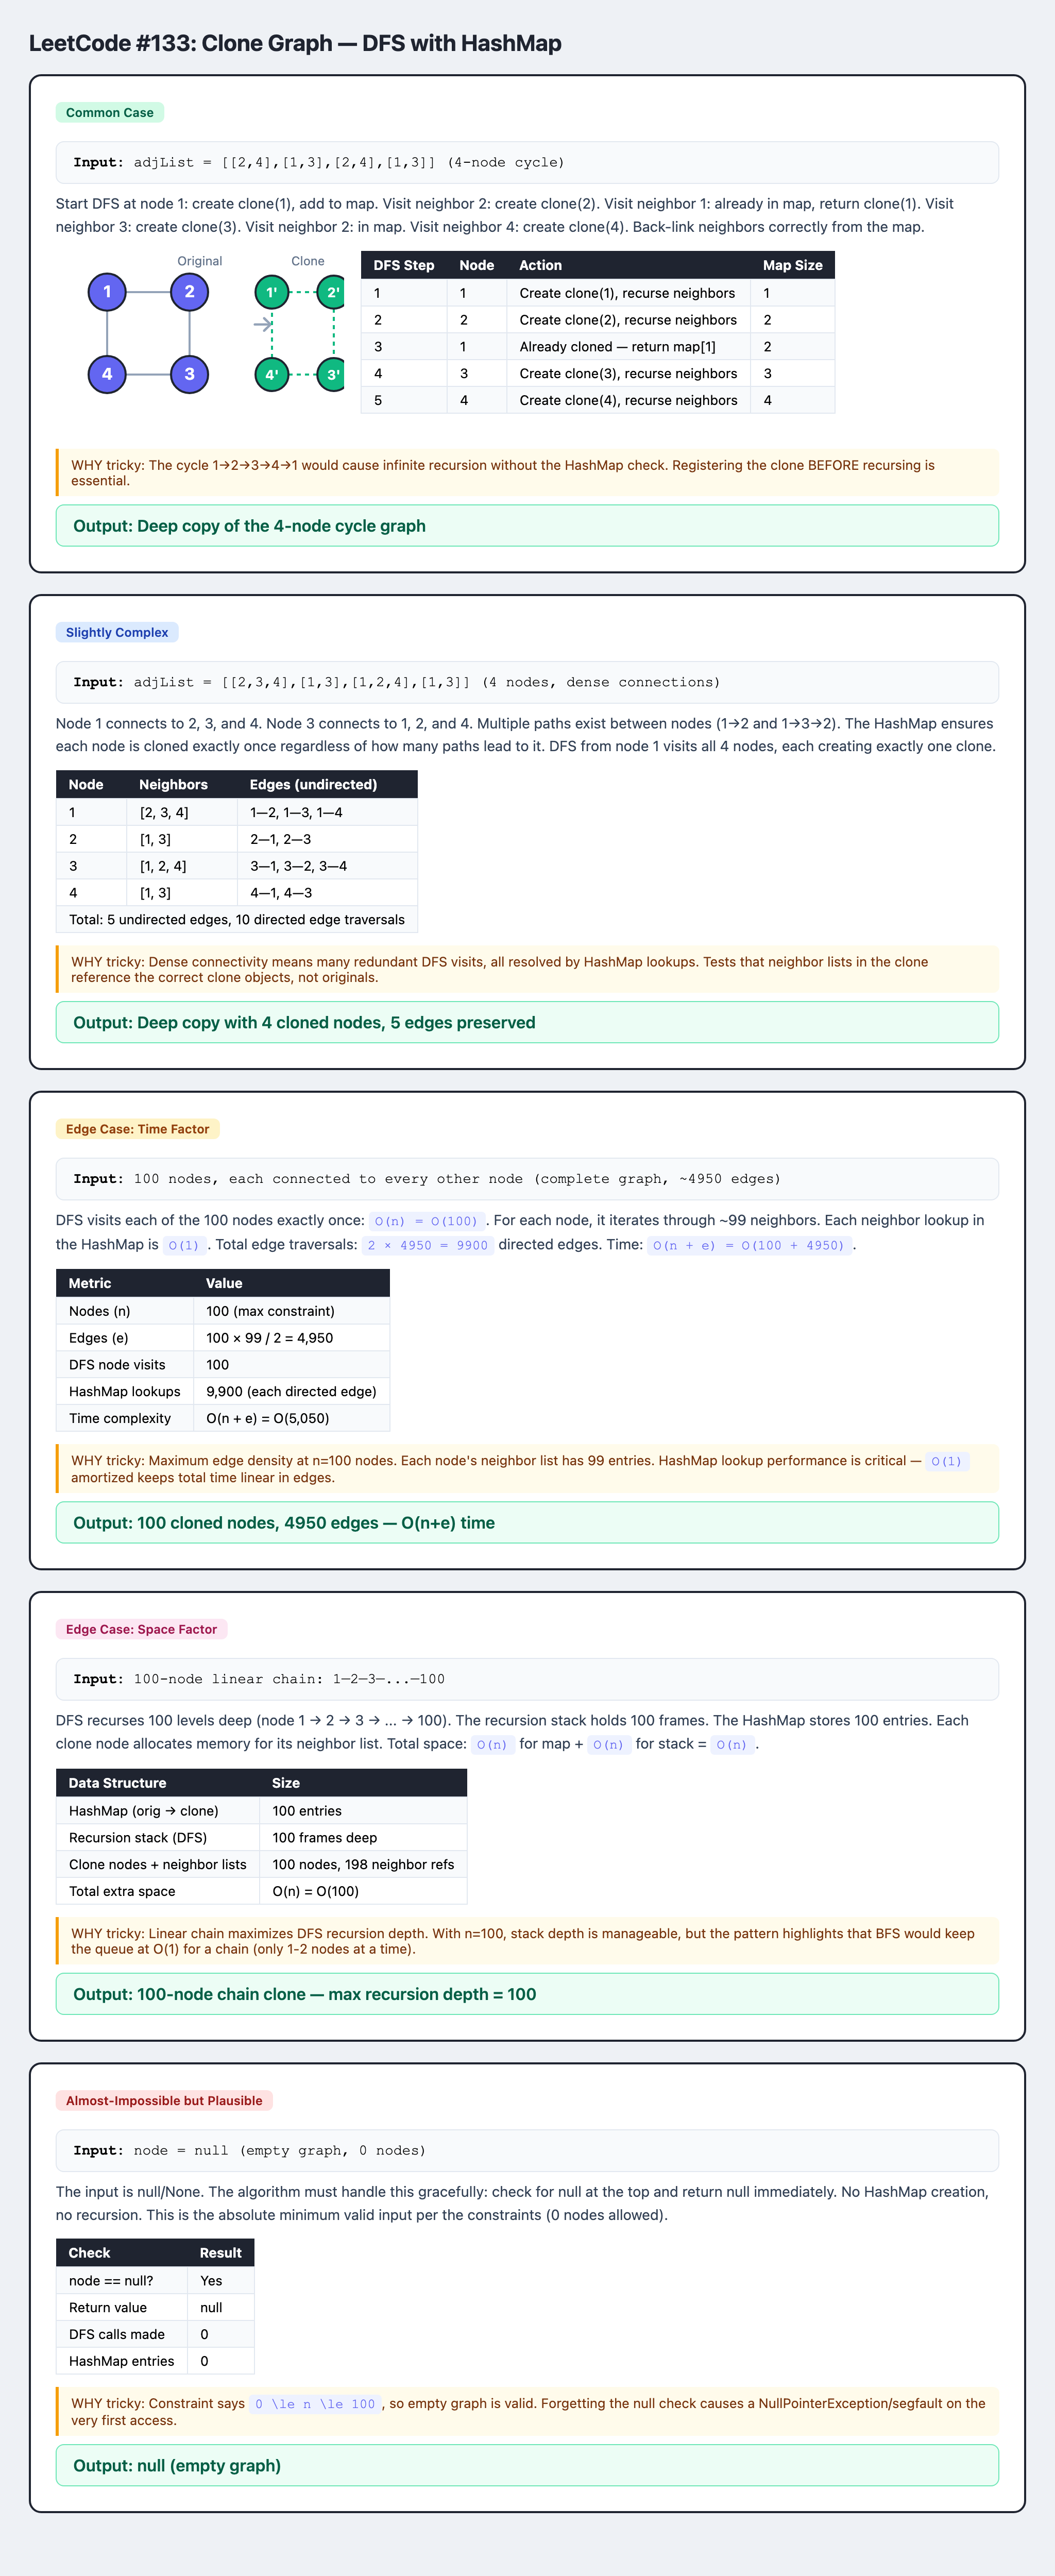